<a href="https://colab.research.google.com/github/thaissanchesroque/Projetos/blob/main/Projeto_de_Arvore_de_Decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score
from google.colab import drive
import os

if os.path.exists('/content/drive/MyDrive/Colab Notebooks'):
    os.chdir('/content/drive/MyDrive/Colab Notebooks')

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [27]:

X_treino = pd.read_csv('X_treino.csv')
y_treino = pd.read_csv('y_treino.csv')['Credit Score']
X_teste = pd.read_csv('X_teste.csv')
y_teste = pd.read_csv('y_teste.csv')['Credit Score']

nomes_classes = {0: 'Average', 1: 'High', 2: 'Low'}

print(f'Treino -> X: {X_treino.shape} | y: {y_treino.shape}')
print(f'Teste  -> X: {X_teste.shape} | y: {y_teste.shape}')
print()
print('Colunas de X:', list(X_treino.columns))
print('Colunas iguais em treino e teste:', list(X_treino.columns) == list(X_teste.columns))
print('Credit Score dentro de X?', 'Credit Score' in X_treino.columns)
print()
print('Distribuição de y_treino:')
print(y_treino.map(nomes_classes).value_counts())
print()
print('Distribuição de y_teste:')
print(y_teste.map(nomes_classes).value_counts())

Treino -> X: (270, 10) | y: (270,)
Teste  -> X: (33, 10) | y: (33,)

Colunas de X: ['Age', 'Income', 'Number of Children', 'Gender_Male', "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Single', 'Home Ownership_Rented']
Colunas iguais em treino e teste: True
Credit Score dentro de X? False

Distribuição de y_treino:
Credit Score
High       90
Low        90
Average    90
Name: count, dtype: int64

Distribuição de y_teste:
Credit Score
High       23
Average     7
Low         3
Name: count, dtype: int64


**Verificação das bases:**

**Linhas:** o treino tem 270 registros em X e em y, e o teste tem 33 em X e em y. Os tamanhos batem dentro de cada base. São as mesmas bases usadas no Módulo 20 (treino balanceado com SMOTE no Módulo 17).

**Variáveis:** X tem 10 colunas: 3 numéricas (Age, Income, Number of Children) e 7 criadas pelo One Hot Encoding. As colunas são iguais em treino e teste e `Credit Score` não está em X, então não há vazamento do alvo. Y contém apenas o score, codificado como 0 = Average, 1 = High e 2 = Low.

**Balanceamento:** `y_treino` está balanceado (90 clientes por classe). `y_teste` **não** está balanceado (23 High, 7 Average, 3 Low), e isso é o correto: o SMOTE foi aplicado apenas no treino, e o teste mantém a proporção real da base para que a avaliação reflita o cenário real.

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

**Passo a passo para aplicar a árvore de decisão:**

1. **Preparar os dados:** tratar faltantes, transformar variáveis categóricas em numéricas, separar X (variáveis explicativas) e y (Credit Score), dividir em treino e teste e, se necessário, balancear apenas o treino. Isso já foi feito no Módulo 17.
2. **Instanciar o modelo:** criar o `DecisionTreeClassifier`, escolhendo o critério de divisão (aqui, **Gini**, que mede a impureza de um nó: quanto mais misturadas as classes, maior o Gini) e fixando `random_state=0` para o resultado ser reproduzível.
3. **Treinar (`fit`):** a árvore procura, entre todas as variáveis e pontos de corte, a pergunta que mais reduz a impureza (ex.: "Income <= 38.750?"). Ela repete isso em cada ramo até os nós ficarem puros ou até atingir algum limite definido.
4. **Prever (`predict`):** cada cliente percorre as perguntas da raiz até uma folha, e recebe a classe da folha.
5. **Avaliar:** comparar as previsões com os valores reais no **treino** e no **teste**, usando acurácia, recall macro (dá o mesmo peso às três classes, importante porque o teste é desbalanceado) e matriz de confusão. A comparação treino x teste mostra se há **overfitting** (treino muito melhor que teste).
6. **Interpretar:** plotar a árvore, ver a profundidade, as regras e a importância das variáveis.

**Como melhorar o modelo:**

- **Controlar o crescimento da árvore (poda):** limitar `max_depth`, exigir um mínimo de clientes por folha (`min_samples_leaf`) ou por divisão (`min_samples_split`), ou usar a poda por custo-complexidade (`ccp_alpha`). Sem limites, a árvore tende a criar folhas com 1 ou 2 clientes, que decoram o treino.
- **Ajustar hiperparâmetros com validação cruzada** (`GridSearchCV`), escolhendo a configuração pelo desempenho médio em vários recortes, e não num único teste.
- **Seleção de variáveis:** manter as que têm importância relevante, simplificando o modelo.
- **Melhorar os dados:** mais clientes, remoção de registros duplicados e um teste maior para uma avaliação mais confiável.
- **Métodos de conjunto:** Random Forest ou Gradient Boosting combinam várias árvores e costumam ser mais estáveis que uma árvore sozinha.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [28]:
arvore = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore.fit(X_treino, y_treino)

y_pred_treino = arvore.predict(X_treino)
acuracia_treino = accuracy_score(y_treino, y_pred_treino)
recall_treino = recall_score(y_treino, y_pred_treino, average='macro')
print(f'Acurácia (treino): {acuracia_treino:.4f}')
print(f'Recall macro (treino): {recall_treino:.4f}')

Acurácia (treino): 1.0000
Recall macro (treino): 1.0000


**Resultado no treino:** acurácia de **100%**. A árvore classificou corretamente todos os 270 clientes do treino. Isso é esperado numa árvore sem limite de crescimento: ela continua dividindo até cada folha ficar pura, então praticamente "decora" o treino. Por isso esse número sozinho não prova que o modelo é bom; a avaliação que importa é no teste.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acurácia (teste): 1.0000
Recall macro (teste): 1.0000

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         7
        High       1.00      1.00      1.00        23
         Low       1.00      1.00      1.00         3

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



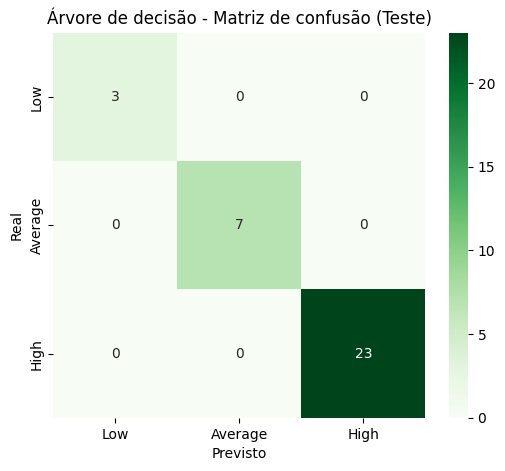

              Treino  Teste
Acurácia         1.0    1.0
Recall macro     1.0    1.0


In [29]:
y_pred_teste = arvore.predict(X_teste)
acuracia_teste = accuracy_score(y_teste, y_pred_teste)
recall_teste = recall_score(y_teste, y_pred_teste, average='macro')
print(f'Acurácia (teste): {acuracia_teste:.4f}')
print(f'Recall macro (teste): {recall_teste:.4f}')
print()
print(classification_report(y_teste, y_pred_teste, target_names=['Average', 'High', 'Low']))

ordem = [2, 0, 1]
rotulos = [nomes_classes[c] for c in ordem]
cm_teste = confusion_matrix(y_teste, y_pred_teste, labels=ordem)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_teste, annot=True, fmt='d', cmap='Greens', xticklabels=rotulos, yticklabels=rotulos)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Árvore de decisão - Matriz de confusão (Teste)')
plt.show()

print(pd.DataFrame({'Treino': [acuracia_treino, recall_treino], 'Teste': [acuracia_teste, recall_teste]},
                   index=['Acurácia', 'Recall macro']).round(4))

**Avaliação no teste:** acurácia de **100%** e recall macro de **100%**. Os 33 clientes foram classificados corretamente, incluindo os 3 clientes Low, a classe mais rara e a mais importante para o negócio (maior risco de crédito). A matriz de confusão tem todos os valores na diagonal.

**Comparação treino x teste:** o desempenho é igual nas duas bases (100%), então **não há sinal de overfitting nesta avaliação**: a árvore manteve o acerto em clientes que não viu no treino.

**Senso crítico:** como já investigado no Módulo 20, o resultado perfeito tem explicações. O problema é muito separável (no teste, todos os High moram em casa própria e todos os Low moram de aluguel), o teste é pequeno (33 clientes, só 3 Low, então cada erro vale cerca de 3 pontos de acurácia) e parte dos clientes do teste tem perfil idêntico a clientes do treino por causa de duplicados na base original. O resultado é bom, mas deve ser confirmado com mais dados.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

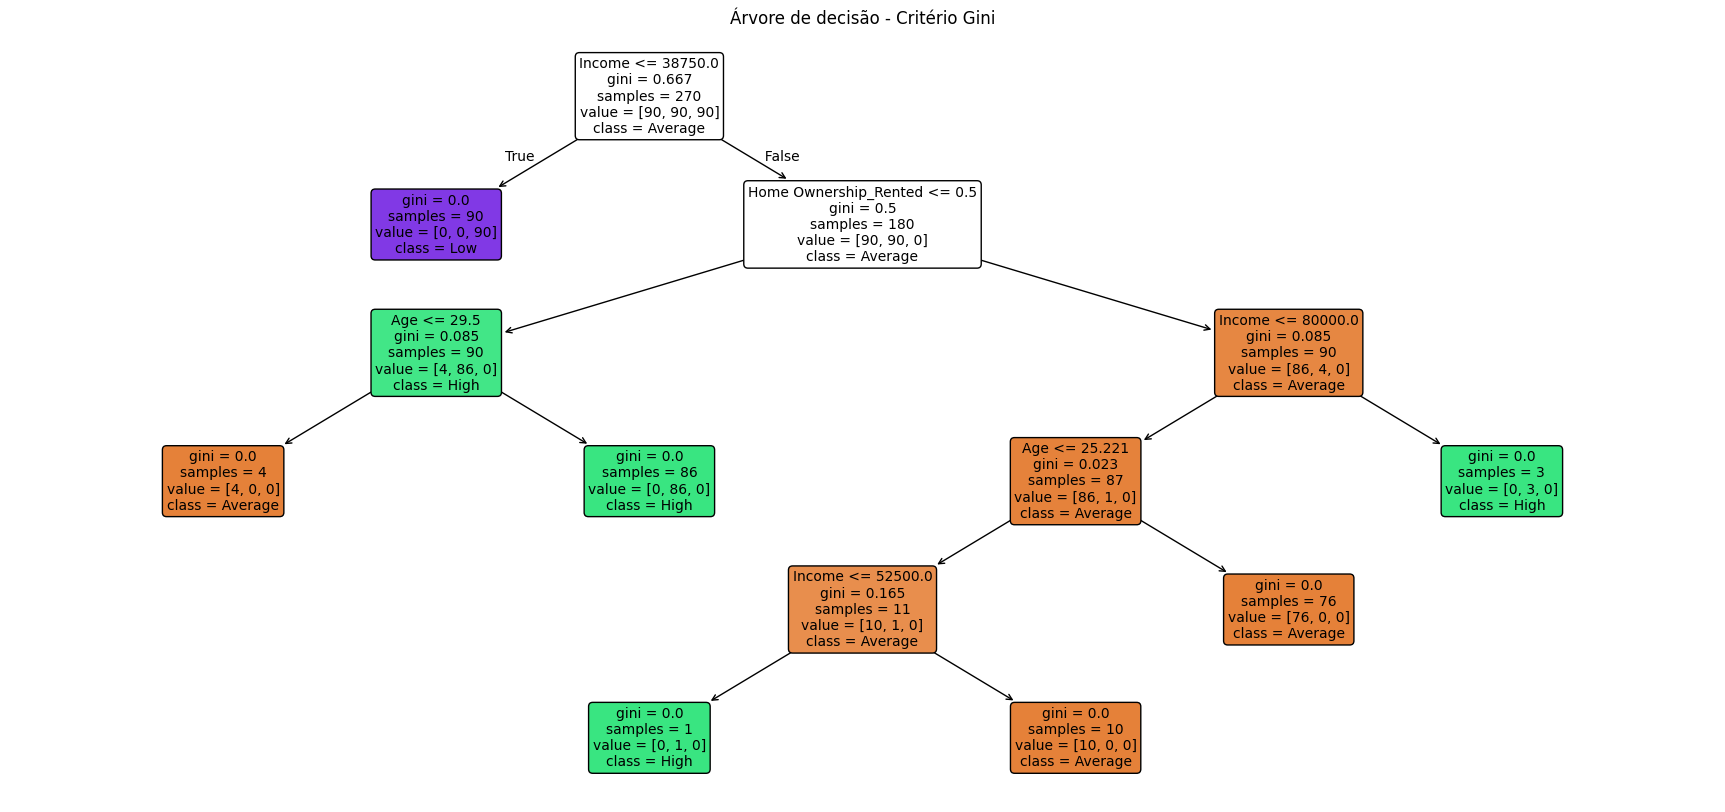

Profundidade da árvore: 5
Número de folhas: 7
Número total de nós: 13


In [30]:
plt.figure(figsize=(22, 10))
plot_tree(arvore, feature_names=list(X_treino.columns), class_names=['Average', 'High', 'Low'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árvore de decisão - Critério Gini')
plt.show()

print('Profundidade da árvore:', arvore.get_depth())
print('Número de folhas:', arvore.get_n_leaves())
print('Número total de nós:', arvore.tree_.node_count)

**Sim, é possível fazer uma avaliação visual.** A árvore é pequena: **profundidade 5**, **7 folhas** e 13 nós no total, o que permite ler cada regra de decisão.

**Leitura da árvore:**

- **Raiz: `Income <= 38.750`.** Essa primeira pergunta já separa sozinha todos os 90 clientes **Low** (folha com Gini = 0). Renda baixa é o principal sinal de risco.
- **Segundo nível: `Home Ownership_Rented`.** Entre os clientes com renda acima de 38.750, a moradia separa quase perfeitamente os grupos: quem tem casa própria vai para um nó com 86 High e 4 Average, e quem mora de aluguel vai para um nó com 86 Average e 4 High.
- **Níveis seguintes: `Age` e novamente `Income`.** Servem apenas para "limpar" poucos casos restantes: clientes com casa própria e até 29,5 anos viram Average; clientes de aluguel com renda acima de 80.000 viram High.

**Variáveis usadas:** apenas **Income, Home Ownership_Rented e Age**. As outras 7 variáveis (gênero, escolaridade, estado civil, filhos) não aparecem em nenhuma divisão.

**Ponto de atenção:** os últimos níveis criam folhas com muito poucos clientes (uma folha com 1 cliente, outras com 3 e 4). Essas regras são específicas demais e são o sinal típico de uma árvore que cresceu sem limite. É exatamente onde a poda (`max_depth`, `min_samples_leaf`) ajudaria, como citado na questão 2.

# 6) Identifique as 2 principais features do modelo.


Income                           0.5416
Home Ownership_Rented            0.4151
Age                              0.0434
Number of Children               0.0000
Education_Bachelor's Degree      0.0000
Gender_Male                      0.0000
Education_Doctorate              0.0000
Education_High School Diploma    0.0000
Education_Master's Degree        0.0000
Marital Status_Single            0.0000
dtype: float64


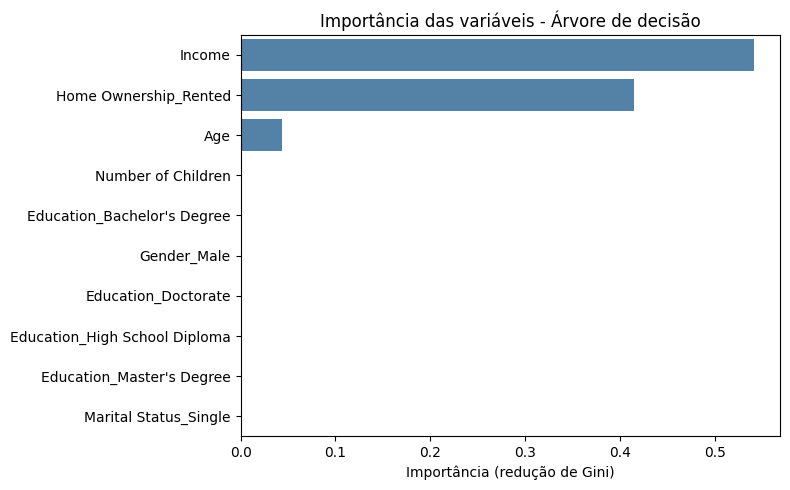

In [31]:
importancias = pd.Series(arvore.feature_importances_, index=X_treino.columns).sort_values(ascending=False)
print(importancias.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, color='steelblue')
plt.title('Importância das variáveis - Árvore de decisão')
plt.xlabel('Importância (redução de Gini)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**As 2 principais features são `Income` (importância ≈ 0,54) e `Home Ownership_Rented` (≈ 0,42).** Juntas somam cerca de 96% da importância do modelo. `Age` aparece com cerca de 4%, e as demais variáveis têm importância zero porque não foram usadas em nenhuma divisão.

Isso confirma a leitura visual da árvore: renda e tipo de moradia são as perguntas do topo, que separam a maior parte dos clientes, e está de acordo com a análise bivariada do Módulo 17, onde moradia e renda já apareciam fortemente relacionadas ao score.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

                    Árvore completa (10 features)  Árvore 2 features
Acurácia treino                               1.0             0.9963
Acurácia teste                                1.0             0.9697
Recall macro teste                            1.0             0.9524
Profundidade                                  5.0             6.0000
Folhas                                        7.0            12.0000


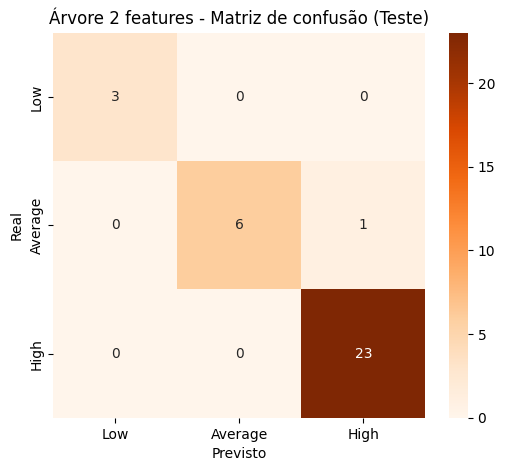

In [32]:
features_top2 = ['Income', 'Home Ownership_Rented']

arvore_top2 = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore_top2.fit(X_treino[features_top2], y_treino)

y_pred_treino_top2 = arvore_top2.predict(X_treino[features_top2])
y_pred_teste_top2 = arvore_top2.predict(X_teste[features_top2])

comparacao = pd.DataFrame({
    'Árvore completa (10 features)': [accuracy_score(y_treino, y_pred_treino), accuracy_score(y_teste, y_pred_teste),
                                      recall_score(y_teste, y_pred_teste, average='macro'), arvore.get_depth(), arvore.get_n_leaves()],
    'Árvore 2 features': [accuracy_score(y_treino, y_pred_treino_top2), accuracy_score(y_teste, y_pred_teste_top2),
                          recall_score(y_teste, y_pred_teste_top2, average='macro'), arvore_top2.get_depth(), arvore_top2.get_n_leaves()]
}, index=['Acurácia treino', 'Acurácia teste', 'Recall macro teste', 'Profundidade', 'Folhas']).round(4)
print(comparacao)

cm_top2 = confusion_matrix(y_teste, y_pred_teste_top2, labels=ordem)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_top2, annot=True, fmt='d', cmap='Oranges', xticklabels=rotulos, yticklabels=rotulos)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Árvore 2 features - Matriz de confusão (Teste)')
plt.show()

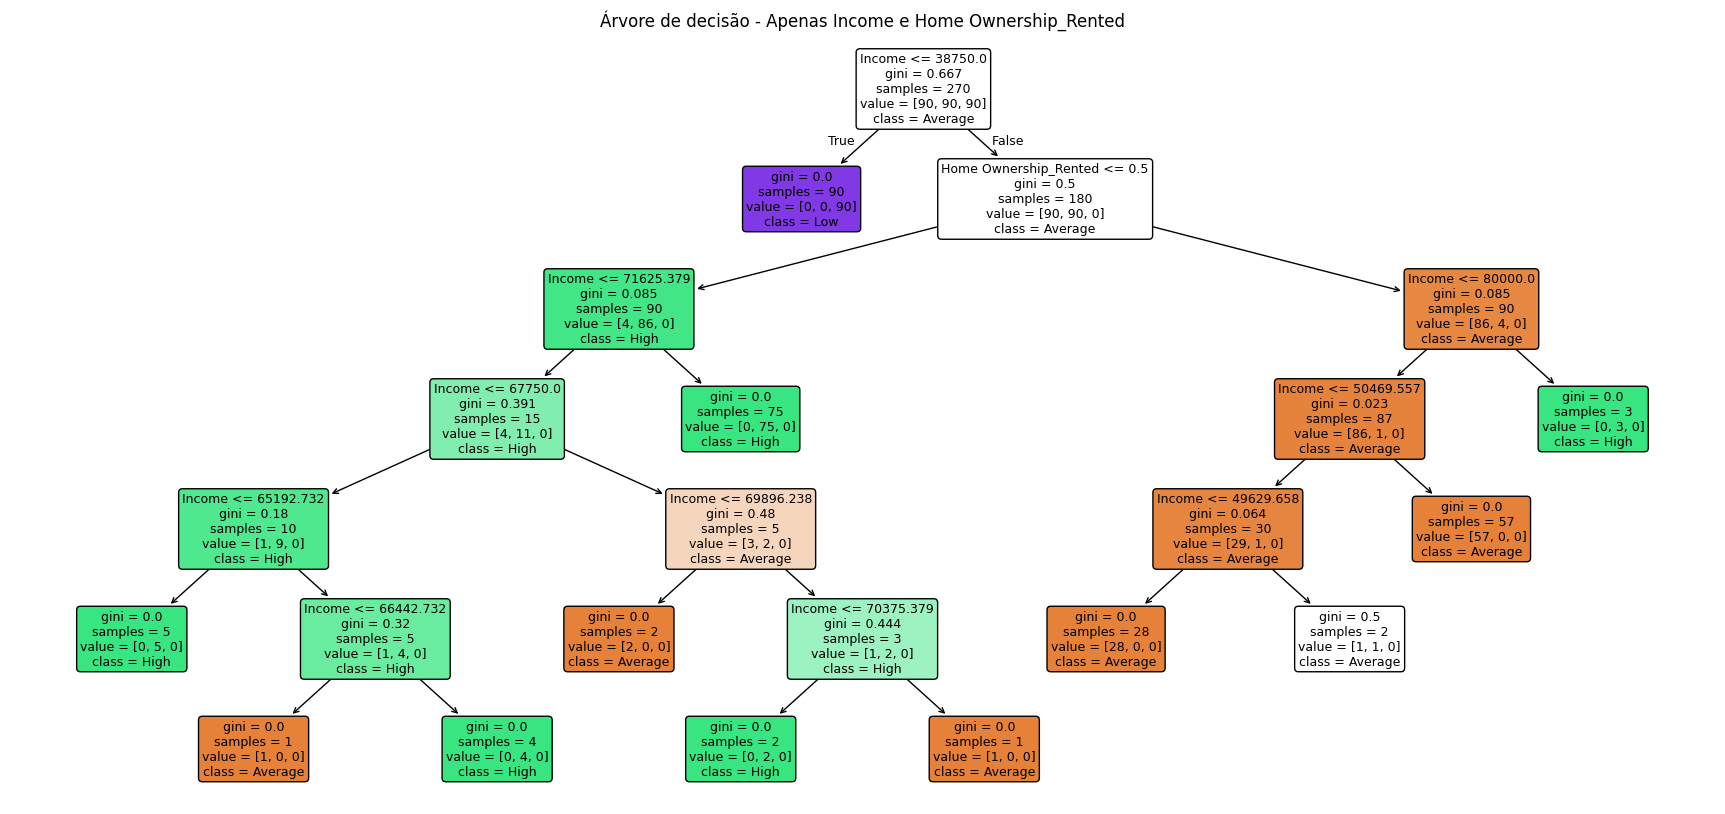

,Income,Home Ownership_Rented,Age,Real,Previsto
0,55000.0,0,26.0,Average,High


In [33]:
plt.figure(figsize=(22, 10))
plot_tree(arvore_top2, feature_names=features_top2, class_names=['Average', 'High', 'Low'],
          filled=True, rounded=True, fontsize=9)
plt.title('Árvore de decisão - Apenas Income e Home Ownership_Rented')
plt.show()

erros = X_teste.loc[y_teste != y_pred_teste_top2, features_top2 + ['Age']].copy()
erros['Real'] = y_teste[erros.index].map(nomes_classes)
erros['Previsto'] = pd.Series(y_pred_teste_top2, index=X_teste.index)[erros.index].map(nomes_classes)
erros

**Resultado:** a árvore com apenas Income e Home Ownership_Rented teve **99,6% de acurácia no treino e 97,0% no teste** (recall macro de 95,2% no teste). Ela errou 1 dos 33 clientes do teste: um cliente **Average classificado como High**. Os 3 clientes Low continuaram todos corretos.

**Na minha avaliação, o desempenho ficou pior que o do modelo anterior**, por três motivos:

1. **Métrica:** caiu de 100% para 97% no teste. A diferença é de 1 cliente, o que num teste de 33 é pouco, mas vai na direção de piora.
2. **Complexidade:** a árvore ficou **mais profunda (6 contra 5) e com mais folhas (12 contra 7)**, ou seja, menos simples e menos interpretável, o contrário do que se espera de uma seleção de features.
3. **Causa:** sem a variável `Age`, a árvore perdeu a regra que separava clientes jovens de casa própria (Average) dos demais (High). Para compensar, ela passou a fazer vários cortes muito próximos em `Income` (ex.: 65.192, 66.442, 67.750, 69.896, 70.375), que são regras artificiais criadas em cima dos clientes sintéticos do SMOTE e não fazem sentido de negócio. O cliente errado no teste é justamente um cliente Average de casa própria, o caso que dependia da idade.

**Conclusão da etapa:** Income e Home Ownership_Rented carregam quase toda a informação, mas `Age`, mesmo com só 4% de importância, resolve um caso específico que as outras duas não conseguem. A seleção de features mais adequada aqui seria manter as **3** variáveis usadas pela árvore original.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [34]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
naive_bayes.fit(X_treino, y_treino)
y_pred_treino_nb = naive_bayes.predict(X_treino)
y_pred_teste_nb = naive_bayes.predict(X_teste)

def metricas(y_tr, p_tr, y_te, p_te):
    return [accuracy_score(y_tr, p_tr), recall_score(y_tr, p_tr, average='macro'),
            accuracy_score(y_te, p_te), recall_score(y_te, p_te, average='macro')]

resultado_final = pd.DataFrame({
    'Naive Bayes (M20)': metricas(y_treino, y_pred_treino_nb, y_teste, y_pred_teste_nb),
    'Árvore completa': metricas(y_treino, y_pred_treino, y_teste, y_pred_teste),
    'Árvore 2 features': metricas(y_treino, y_pred_treino_top2, y_teste, y_pred_teste_top2)
}, index=['Acurácia treino', 'Recall macro treino', 'Acurácia teste', 'Recall macro teste']).round(4)
resultado_final

,Naive Bayes (M20),Árvore completa,Árvore 2 features
Acurácia treino,0.9963,1.0,0.9963
Recall macro treino,0.9963,1.0,0.9963
Acurácia teste,1.0000,1.0,0.9697
Recall macro teste,1.0000,1.0,0.9524


**Comparação (mesmas bases de treino e teste nos três modelos):**

| Modelo | Acurácia treino | Acurácia teste | Recall macro teste |
|---|---|---|---|
| Naive Bayes (M20) | 99,63% | 100% | 100% |
| Árvore de decisão (10 features) | 100% | 100% | 100% |
| Árvore de decisão (2 features) | 99,63% | 96,97% | 95,24% |

**Nas métricas, o Naive Bayes e a árvore completa empataram no teste:** os dois acertaram os 33 clientes, inclusive os 3 Low. No treino a árvore fez 100% e o Naive Bayes 99,6% (1 erro), mas treino não é critério de escolha, e o 100% da árvore no treino é consequência de ela crescer até as folhas ficarem puras.

**Para mim, a árvore de decisão completa se adequou melhor a este problema**, e a justificativa não está na acurácia, e sim nestes pontos:

1. **Interpretabilidade:** a árvore entrega regras explícitas ("renda até 38.750 → Low"; "renda maior e casa própria → High"). Em crédito, que é um setor regulado, é preciso explicar por que um cliente foi aprovado ou negado, e o Naive Bayes só entrega probabilidades, sem uma regra legível.
2. **Aderência à estrutura dos dados:** o score nesta base é definido por cortes claros de renda e pela moradia, que é exatamente o tipo de padrão que a árvore captura. O Naive Bayes assume que as variáveis são independentes entre si, o que não é verdade aqui (idade e renda têm correlação de cerca de 0,69 no Módulo 17), e mesmo assim funcionou porque o problema é muito separável.
3. **Seleção de variáveis embutida:** a árvore mostrou que só 3 das 10 variáveis importam, informação útil para o negócio que o Naive Bayes não fornece diretamente.

**Limitação importante:** com um teste de apenas 33 clientes e desempenho de 100% nos dois modelos, **os dados não permitem afirmar que um é mais preciso que o outro**. Para desempatar pela métrica seria preciso uma base de teste maior ou validação cruzada. Além disso, a árvore sem poda tem folhas com 1 a 4 clientes, então antes de usá-la em produção valeria aplicar `max_depth` ou `min_samples_leaf` para torná-la mais robusta.